In [1]:
pip install -r requirements.txt

  Obtaining dependency information for pandas from https://files.pythonhosted.org/packages/98/af/7be05277859a7bc399da8ba68b88c96b27b48740b6cf49688899c6eb4176/pandas-2.3.3-cp39-cp39-win_amd64.whl.metadata
  Obtaining dependency information for numpy from https://files.pythonhosted.org/packages/ea/2b/7fc9f4e7ae5b507c1a3a21f0f15ed03e794c1242ea8a242ac158beb56034/numpy-2.0.2-cp39-cp39-win_amd64.whl.metadata
  Using cached numpy-2.0.2-cp39-cp39-win_amd64.whl.metadata (59 kB)
  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/57/68/c2feb4667adbf882ffa4b3e0ac9967f848980d9f8b5bebd86644aa67ce6a/matplotlib-3.9.4-cp39-cp39-win_amd64.whl.metadata
  Using cached matplotlib-3.9.4-cp39-cp39-win_amd64.whl.metadata (11 kB)
  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metadata
  Using cached seaborn-0.13.2-py3-none-an


[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
!pip install pillow-heif


[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from PIL import Image
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


In [5]:
import tensorflow as tf
import os

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # Hilangkan log warning CPU

print(f"TensorFlow Version: {tf.__version__}") # Harus 2.10.x
print(f"Python Version: {sys.version}") # Harus 3.9.x

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ SUKSES! GPU Terdeteksi: {gpus}")
    print("RTX 4060 Anda siap digunakan untuk training.")
else:
    print("❌ GAGAL. Masih menggunakan CPU.")

TensorFlow Version: 2.20.0
Python Version: 3.9.13 (tags/v3.9.13:6de2ca5, May 17 2022, 16:36:42) [MSC v.1929 64 bit (AMD64)]
❌ GAGAL. Masih menggunakan CPU.


In [23]:
import os
from PIL import Image
from tqdm import tqdm
import pandas as pd

# --- KHUSUS HEIC ---
# Daftarkan pembaca HEIC agar Image.open() bisa membacanya
try:
    from pillow_heif import register_heif_opener
    register_heif_opener()
    print("Support HEIC berhasil diaktifkan.")
except ImportError:
    print("Library 'pillow-heif' belum terinstall. Jalankan '!pip install pillow-heif' dulu.")

# ==========================================
# KONVERSI SEMUA DATA (TERMASUK HEIC) KE PNG
# ==========================================

output_base_dir = 'DENGAN LEMPUK PNG'  # Folder tujuan
print(f"\nMemulai konversi gambar ke PNG...")
print(f"Data akan disimpan di: {output_base_dir}")

new_data_list = []
error_files = []

# Menggunakan tqdm untuk progress bar
for index, row in tqdm(df.iterrows(), total=df.shape[0], desc="Converting"):
    src_path = row['filepath']
    label = row['label']  
    
    # 1. Persiapan Folder Tujuan
    parts = label.split() 
    variation_folder = parts[0] # V1
    quality_folder = parts[1]   # GOOD
    
    target_folder = os.path.join(output_base_dir, quality_folder, variation_folder)
    os.makedirs(target_folder, exist_ok=True)
    
    # 2. Nama File Baru (.png)
    file_name = os.path.basename(src_path)
    name_without_ext = os.path.splitext(file_name)[0]
    new_filename = f"{name_without_ext}.png"
    dst_path = os.path.join(target_folder, new_filename)
    
    # 3. Proses Konversi
    try:
        # Image.open sekarang sudah bisa buka HEIC karena register_heif_opener()
        with Image.open(src_path) as img:
            
            # Convert ke RGB 
            # (Penting: HEIC/PNG bisa punya alpha channel/transparansi, 
            # untuk deep learning amannya dipaksa ke RGB 3-channel)
            img = img.convert('RGB')
            
            # Simpan sebagai PNG
            img.save(dst_path, 'PNG')
            
            # Masukkan path baru ke list
            new_data_list.append({'filepath': dst_path, 'label': label})
            
    except Exception as e:
        print(f"\n[ERROR] Gagal: {src_path} | Error: {e}")
        error_files.append(src_path)

# ==========================================
# UPDATE DATAFRAME
# ==========================================
df_png = pd.DataFrame(new_data_list)
df = df_png # Timpa df lama dengan data PNG baru

print("\n" + "="*40)
print("KONVERSI SELESAI")
print("="*40)
print(f"Total Asli  : {len(df) + len(error_files)}")
print(f"Berhasil PNG: {len(df_png)}")
print(f"Gagal       : {len(error_files)}")

if len(error_files) > 0:
    print("Contoh file gagal:", error_files[:3])

Support HEIC berhasil diaktifkan.

Memulai konversi gambar ke PNG...
Data akan disimpan di: DENGAN LEMPUK_PNG_DATASET


Converting: 100%|██████████| 160/160 [02:01<00:00,  1.32it/s]


KONVERSI SELESAI
Total Asli  : 160
Berhasil PNG: 160
Gagal       : 0


## LOAD DATA

In [3]:
# ==========================================
# 1. MOUNT GOOGLE DRIVE & PERSIAPAN DATA
# ==========================================


# --- KONFIGURASI FOLDER ---
# Pastikan path ini sesuai dengan di Drive Anda
base_dir = 'DENGAN LEMPUK PNG'

# List Variasi dan Kualitas sesuai struktur folder Anda
qualities = ['GOOD', "BAD"]
# qualities = ['GOOD']
variations = ['V1', 'V2', 'V3', 'V4']
print("Sedang memindai file dan membuat label...")

data_list = []

# Loop untuk membaca file dari struktur folder
for quality in qualities:

  for variation in variations:
      # Menyusun path: .../TANPA LEMPUK/GOOD/Variasi 1
      folder_path = os.path.join(base_dir, quality, variation)
        
      if os.path.exists(folder_path):
          files = os.listdir(folder_path)
          for file_name in files:
              if file_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.heic')):
                  # Membuat Label: "Variasi 1 GOOD", dst.
                  label_name = f"{variation} {quality}" 
                  full_path = os.path.join(folder_path, file_name)
                  data_list.append({'filepath': full_path, 'label': label_name})
      else:
          print(f"Warning: Folder tidak ditemukan -> {folder_path}")

# Konversi ke DataFrame
df = pd.DataFrame(data_list)
print(f"\nTotal Data Ditemukan: {len(df)}")
print(f"Jumlah Kelas: {df['label'].nunique()}")

# Cek distribusi data
print("\nJumlah data per kelas:")
print(df['label'].value_counts())

Sedang memindai file dan membuat label...

Total Data Ditemukan: 160
Jumlah Kelas: 8

Jumlah data per kelas:
label
V1 GOOD    20
V2 GOOD    20
V3 GOOD    20
V4 GOOD    20
V1 BAD     20
V2 BAD     20
V3 BAD     20
V4 BAD     20
Name: count, dtype: int64


In [4]:

# Konversi ke DataFrame
df = pd.DataFrame(data_list)
print(f"\nTotal Data Awal: {len(df)}")
print("Distribusi Awal:")
print(df['label'].value_counts())

# ==========================================
# 2. PROSES UNDERSAMPLING
# ==========================================
print("\n--- Memulai Proses Undersampling ---")

# 1. Cari jumlah sampel terkecil di antara semua kelas
min_sample = df['label'].value_counts().min()
print(f"Jumlah sampel terendah (target undersampling): {min_sample}")

# 2. Lakukan Undersampling
# Groupby label, lalu ambil sample sejumlah 'min_sample' dari setiap grup
df = df.groupby('label', group_keys=False).apply(lambda x: x.sample(min_sample, random_state=42))

# Reset index agar rapi
df = df.reset_index(drop=True)

# 3. Cek Hasil Balancing
print(f"\nTotal Data Setelah Undersampling: {len(df)}")
print("Distribusi Setelah Undersampling:")
print(df['label'].value_counts())


Total Data Awal: 160
Distribusi Awal:
label
V1 GOOD    20
V2 GOOD    20
V3 GOOD    20
V4 GOOD    20
V1 BAD     20
V2 BAD     20
V3 BAD     20
V4 BAD     20
Name: count, dtype: int64

--- Memulai Proses Undersampling ---
Jumlah sampel terendah (target undersampling): 20

Total Data Setelah Undersampling: 160
Distribusi Setelah Undersampling:
label
V1 BAD     20
V1 GOOD    20
V2 BAD     20
V2 GOOD    20
V3 BAD     20
V3 GOOD    20
V4 BAD     20
V4 GOOD    20
Name: count, dtype: int64


C:\Users\Azvadennys\AppData\Local\Temp\ipykernel_9452\1600019215.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('label', group_keys=False).apply(lambda x: x.sample(min_sample, random_state=42))


In [5]:
def visualize_split(train_df, val_df, test_df):
    # ==========================================
    # 1. PIE CHART: Overall Percentage
    # ==========================================
    sizes = [len(train_df), len(val_df), len(test_df)]
    labels = ['Training (70%)', 'Validation (20%)', 'Testing (10%)']
    colors = ['#4CAF50', '#FFC107', '#2196F3']  # Green, Yellow, Blue
    explode = (0.05, 0, 0)  # Slightly separate the Training slice

    plt.figure(figsize=(18, 6))

    # Subplot 1: Pie Chart
    plt.subplot(1, 2, 1)
    plt.pie(
        sizes, labels=labels, colors=colors, autopct='%1.1f%%',
        startangle=140, pctdistance=0.85, explode=explode, shadow=True
    )

    # Create a center circle (Donut Chart) for a more aesthetic look
    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)

    plt.title('Overall Data Split Proportion', fontsize=14, fontweight='bold')
    plt.axis('equal')

    # ==========================================
    # 2. STACKED BAR CHART: Distribution per Class
    # ==========================================
    # Count samples per class for each split
    train_counts = train_df['label'].value_counts().sort_index()
    val_counts = val_df['label'].value_counts().sort_index()
    test_counts = test_df['label'].value_counts().sort_index()

    # Combine counts into a single DataFrame for plotting
    df_counts = pd.DataFrame({
        'Training': train_counts,
        'Validation': val_counts,
        'Testing': test_counts
    })

    # Subplot 2: Stacked Bar Chart
    plt.subplot(1, 2, 2)

    # Plot
    df_counts.plot(kind='bar', stacked=True, color=colors, ax=plt.gca(), width=0.8)

    plt.title('Class-wise Data Distribution (Stratified)', fontsize=14, fontweight='bold')
    plt.xlabel('Class Label')
    plt.ylabel('Number of Images')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Dataset')
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

    # Show detailed table
    print("\nDetailed Sample Count per Class:")
    print(df_counts)


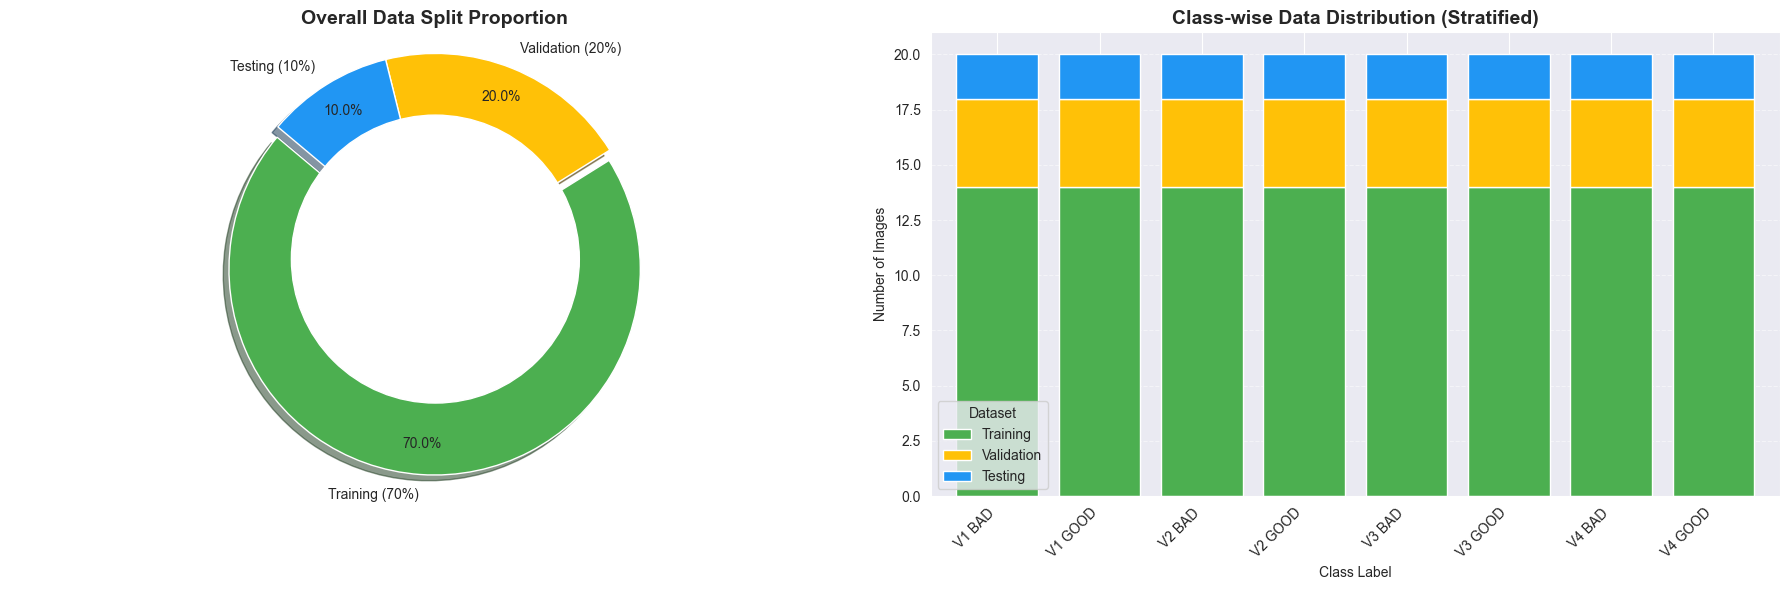


Detailed Sample Count per Class:
         Training  Validation  Testing
label                                 
V1 BAD         14           4        2
V1 GOOD        14           4        2
V2 BAD         14           4        2
V2 GOOD        14           4        2
V3 BAD         14           4        2
V3 GOOD        14           4        2
V4 BAD         14           4        2
V4 GOOD        14           4        2

--- Pembagian Data ---
Training   : 112 (70.0%)
Validation : 32 (20.0%)
Test       : 16 (10.0%)


In [6]:
# ==========================================
# 2. SPLITTING DATA (70% Train, 20% Val, 10% Test)
# ==========================================
# Langkah 1: Pisahkan 70% untuk Training
train_df, temp_df = train_test_split(df, train_size=0.7, stratify=df['label'], random_state=42)

# Langkah 2: Pisahkan sisanya (Temp) menjadi Val dan Test
# Val mengambil 2/3 dari Temp (sehingga totalnya 20% dari keseluruhan)
val_df, test_df = train_test_split(temp_df, train_size=2/3, stratify=temp_df['label'], random_state=42)

visualize_split(train_df, val_df, test_df)

print(f"\n--- Pembagian Data ---")
print(f"Training   : {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"Validation : {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test       : {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")

## AUGMENTASI

In [10]:


# ==========================================
# 3. DATA GENERATOR
# ==========================================
IMG_SIZE = (150, 150)
BATCH_SIZE = 32


train_datagen = ImageDataGenerator(
    rescale=1./255,             # Normalisasi pixel
    rotation_range=30,          # Rotasi gambar hingga 30 derajat
    width_shift_range=0.2,      # Geser gambar secara horizontal
    height_shift_range=0.2,     # Geser gambar secara vertikal
    shear_range=0.2,            # Efek miring (shear)
    zoom_range=0.2,             # Zoom in/out
    horizontal_flip=True,       # Membalik gambar horizontal
    fill_mode='nearest'         # Mengisi pixel kosong akibat rotasi
)

val_test_datagen = ImageDataGenerator(rescale=1./255,
                                      horizontal_flip=True)

# Train Generator
train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df, x_col='filepath', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True
)

# Validation Generator
val_gen = train_datagen.flow_from_dataframe(
    dataframe=val_df, x_col='filepath', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

# Test Generator (Shuffle False agar urutan prediksi sesuai label asli untuk evaluasi)
test_gen = val_test_datagen.flow_from_dataframe(
    dataframe=test_df, x_col='filepath', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

class_names = list(train_gen.class_indices.keys())

Found 112 validated image filenames belonging to 8 classes.
Found 32 validated image filenames belonging to 8 classes.
Found 16 validated image filenames belonging to 8 classes.


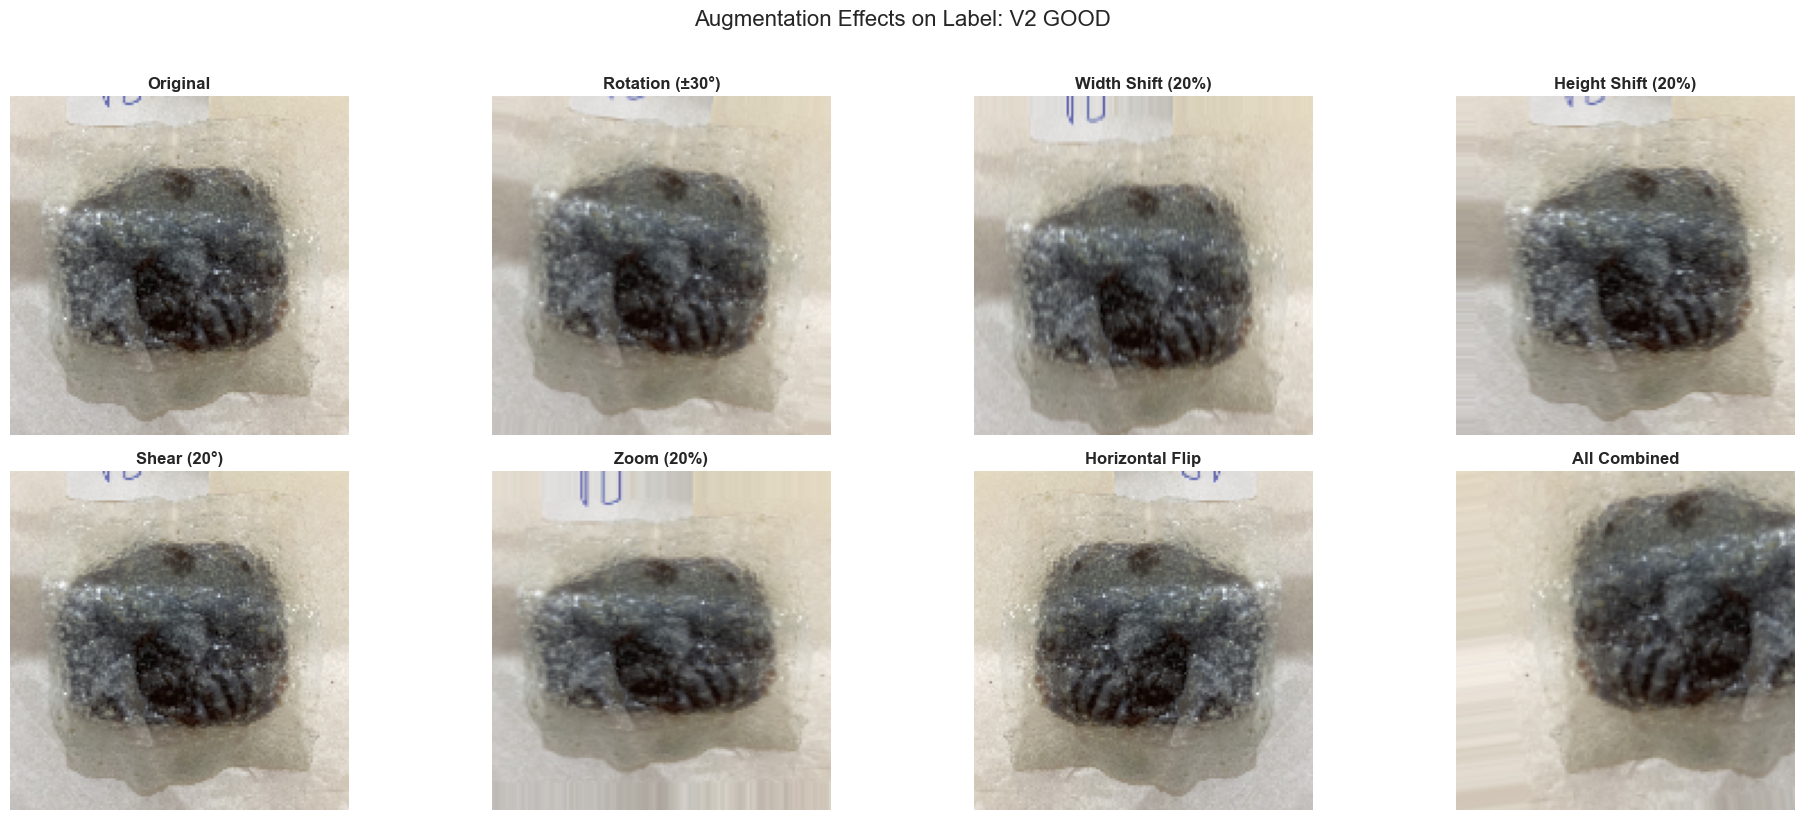

In [12]:
def visualize_specific_augmentations(dataframe):
    # 1. Ambil 1 Gambar Sampel
    sample_row = dataframe.sample(1).iloc[0]
    img_path = sample_row['filepath']
    label = sample_row['label']
    
    # Load dan Preprocess
    img = load_img(img_path, target_size=(150, 150))
    x = img_to_array(img)
    x = x.reshape((1,) + x.shape) # (1, 150, 150, 3)

    # 2. Definisi Parameter Augmentasi Terpisah
    # Kita buat dictionary generator untuk setiap efek
    aug_types = {
        'Original': ImageDataGenerator(rescale=1./255),
        'Rotation (±30°)': ImageDataGenerator(rescale=1./255, rotation_range=30, fill_mode='nearest'),
        'Width Shift (20%)': ImageDataGenerator(rescale=1./255, width_shift_range=0.2, fill_mode='nearest'),
        'Height Shift (20%)': ImageDataGenerator(rescale=1./255, height_shift_range=0.2, fill_mode='nearest'),
        'Shear (20°)': ImageDataGenerator(rescale=1./255, shear_range=0.2, fill_mode='nearest'),
        'Zoom (20%)': ImageDataGenerator(rescale=1./255, zoom_range=0.2, fill_mode='nearest'),
        'Horizontal Flip': ImageDataGenerator(rescale=1./255, horizontal_flip=True),
        'All Combined': ImageDataGenerator(
            rescale=1./255, rotation_range=30, width_shift_range=0.2,
            height_shift_range=0.2, shear_range=0.2, zoom_range=0.2,
            horizontal_flip=True, fill_mode='nearest'
        )
    }

    # 3. Plotting
    plt.figure(figsize=(20, 8))
    plt.suptitle(f"Augmentation Effects on Label: {label}", fontsize=16, y=1.02)

    for i, (name, datagen) in enumerate(aug_types.items()):
        # Generate 1 gambar dari flow
        # Seed diset agar randomness-nya bisa kita kontrol sedikit (opsional)
        gen = datagen.flow(x, batch_size=1, seed=42)
        aug_img = next(gen)[0]
        
        plt.subplot(2, 4, i + 1)
        plt.imshow(aug_img)
        plt.title(name, fontsize=12, fontweight='bold')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Jalankan Fungsi
visualize_specific_augmentations(train_df)

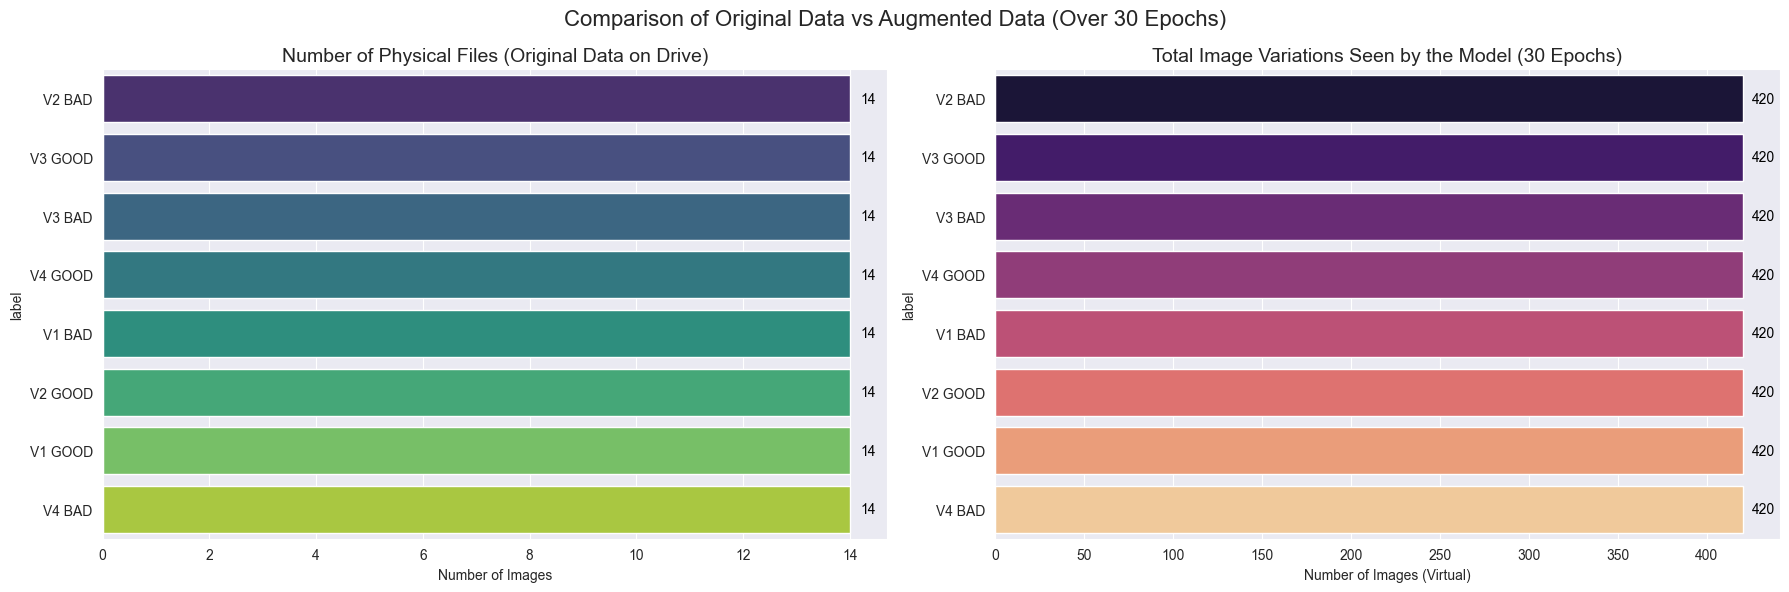


--- EXPLANATION ---
1. Total Original Training Files: 112 images.
2. Since augmentation happens every epoch, over 30 epochs the model will learn from:
   112 x 30 = 3360 different image variations.
3. This is why augmentation is very effective at preventing overfitting even when the original dataset is small.


In [13]:


def visualize_data_expansion(train_df, epochs=30):
    # Count original (physical) data
    original_counts = train_df['label'].value_counts()
    
    # Count virtual data (Original Data x Number of Epochs)
    virtual_counts = original_counts * epochs
    
    classes = original_counts.index
    
    # Plot setup
    fig, ax = plt.subplots(1, 2, figsize=(18, 6))
    
    # Plot 1: Physical (Real) Data
    # FIX: Add hue=classes and legend=False
    sns.barplot(
        x=original_counts.values, y=classes,
        hue=classes, legend=False,
        ax=ax[0], palette='viridis'
    )
    
    ax[0].set_title('Number of Physical Files (Original Data on Drive)', fontsize=14)
    ax[0].set_xlabel('Number of Images')
    for i, v in enumerate(original_counts.values):
        ax[0].text(v + 0.2, i, str(v), color='black', va='center')

    # Plot 2: Virtual Data (Seen by the Model)
    # FIX: Add hue=classes and legend=False
    sns.barplot(
        x=virtual_counts.values, y=classes,
        hue=classes, legend=False,
        ax=ax[1], palette='magma'
    )
    
    ax[1].set_title(f'Total Image Variations Seen by the Model ({epochs} Epochs)', fontsize=14)
    ax[1].set_xlabel('Number of Images (Virtual)')
    for i, v in enumerate(virtual_counts.values):
        ax[1].text(v + 5, i, f"{v:,}", color='black', va='center')  # Thousands format

    plt.suptitle(
        f"Comparison of Original Data vs Augmented Data (Over {epochs} Epochs)",
        fontsize=16
    )
    plt.tight_layout()
    plt.show()
    
    print(f"\n--- EXPLANATION ---")
    print(f"1. Total Original Training Files: {len(train_df)} images.")
    print(f"2. Since augmentation happens every epoch, over {epochs} epochs the model will learn from:")
    print(f"   {len(train_df)} x {epochs} = {len(train_df)*epochs} different image variations.")
    print("3. This is why augmentation is very effective at preventing overfitting even when the original dataset is small.")

# Run the visualization
visualize_data_expansion(train_df, epochs=30)


## TRAINING DATA

In [35]:
# ==========================================
# 4. FUNGSI UTAMA (TRAIN, SAVE, EVALUATE)
# ==========================================
def run_experiment(model, exp_name, epochs=100):
    print(f"\n{'='*15} MULAI: {exp_name} {'='*15}")
    print("Training Device:", tf.test.gpu_device_name() if tf.test.is_gpu_available() else "CPU")
    # 1. Checkpoint: Simpan model terbaik (Best Weights) ke file .keras
    checkpoint_path = f"{exp_name}_best_model.keras"
    checkpoint = callbacks.ModelCheckpoint(
        checkpoint_path, 
        monitor='val_loss', 
        save_best_only=True, 
        mode='min', 
        verbose=1
    )
    
    # 2. Early Stopping: Berhenti jika tidak ada perbaikan
    early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)
    
    # 3. Reduce LR: Kurangi learning rate jika stagnan
    lr_schedule = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
    
    # 4. CSV Logger
    csv_log = callbacks.CSVLogger(f'{exp_name}_training_log.csv')
    
    # --- TRAINING ---
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs,
        callbacks=[checkpoint, early_stop, lr_schedule, csv_log],
        verbose=1
    )
    
    # Simpan model versi terakhir (opsional, backup)
    model.save(f"{exp_name}_final_model.keras")
    print(f"Model berhasil disimpan sebagai: {checkpoint_path}")
    
    return history

def evaluate_and_plot(model, history, exp_name):
    # --- PLOT GRAFIK ---
    metrics_df = pd.DataFrame(history.history)
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    
    # Grafik Akurasi
    sns.lineplot(data=metrics_df[['accuracy', 'val_accuracy']], ax=ax[0])
    ax[0].set_title(f'{exp_name}: Accuracy')
    
    # Grafik Loss
    sns.lineplot(data=metrics_df[['loss', 'val_loss']], ax=ax[1])
    ax[1].set_title(f'{exp_name}: Loss')
    plt.show()

    # --- EVALUASI TEST SET ---
    print(f"\n--- Evaluasi pada Data Test: {exp_name} ---")
    predictions = model.predict(test_gen)
    y_pred = np.argmax(predictions, axis=1)
    y_true = test_gen.classes

    # Classification Report
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')
    plt.title(f'Confusion Matrix: {exp_name}')
    plt.show()
    
input_shape = (IMG_SIZE[0], IMG_SIZE[1], 3)
num_classes = len(class_names)

In [32]:
from tensorflow.keras.applications import DenseNet121


=============== MULAI: Exp1_DenseNet121_Dengan_Lempuk ===============
Training Device: CPU
Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1393 - loss: 2.5922
Epoch 1: val_loss improved from inf to 1.73526, saving model to Exp1_DenseNet121_Dengan_Lempuk_best_model.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 25s 6s/step - accuracy: 0.1615 - loss: 2.5145 - val_accuracy: 0.3750 - val_loss: 1.7353 - learning_rate: 0.0010
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7351 - loss: 0.8042
Epoch 2: val_loss improved from 1.73526 to 1.14848, saving model to Exp1_DenseNet121_Dengan_Lempuk_best_model.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 16s 4s/step - accuracy: 0.7470 - loss: 0.7851 - val_accuracy: 0.5312 - val_loss: 1.1485 - learning_rate: 0.0010
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8717 - loss: 0.4062
Epoch 3: val_loss improved from 1.14848 to 1.07546, saving model to Exp1_DenseNet121_Dengan_Lempuk_best_model.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 16s 4s/step - accur

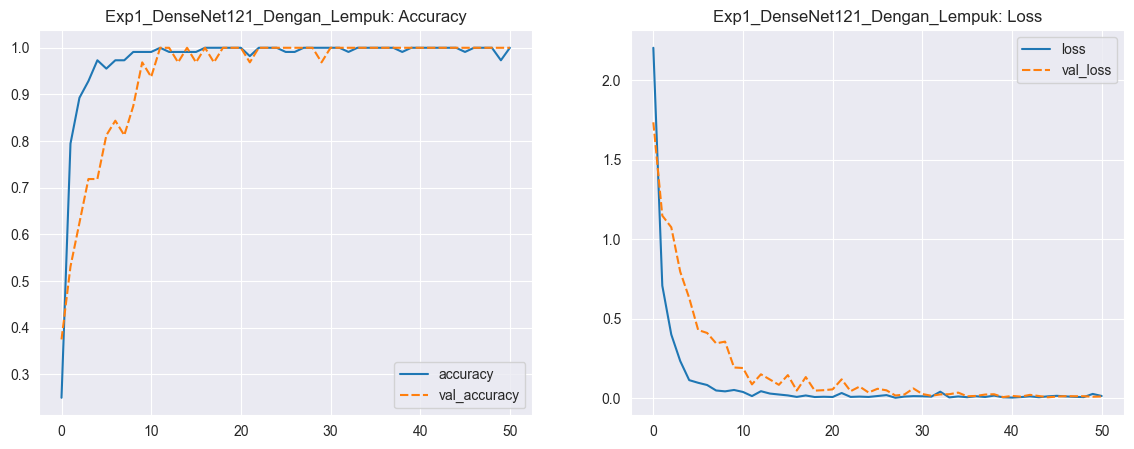


--- Evaluasi pada Data Test: Exp1_DenseNet121_Dengan_Lempuk ---


C:\Users\Azvadennys\Desktop\Training Edible Film\venv-39\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
              precision    recall  f1-score   support

     V1 BAIK       1.00      1.00      1.00         2
    V1 BURUK       1.00      1.00      1.00         2
     V2 BAIK       1.00      1.00      1.00         2
    V2 BURUK       1.00      1.00      1.00         2
     V3 BAIK       1.00      1.00      1.00         2
    V3 BURUK       1.00      1.00      1.00         2
     V4 BAIK       1.00      1.00      1.00         2
    V4 BURUK       1.00      1.00      1.00         2

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16



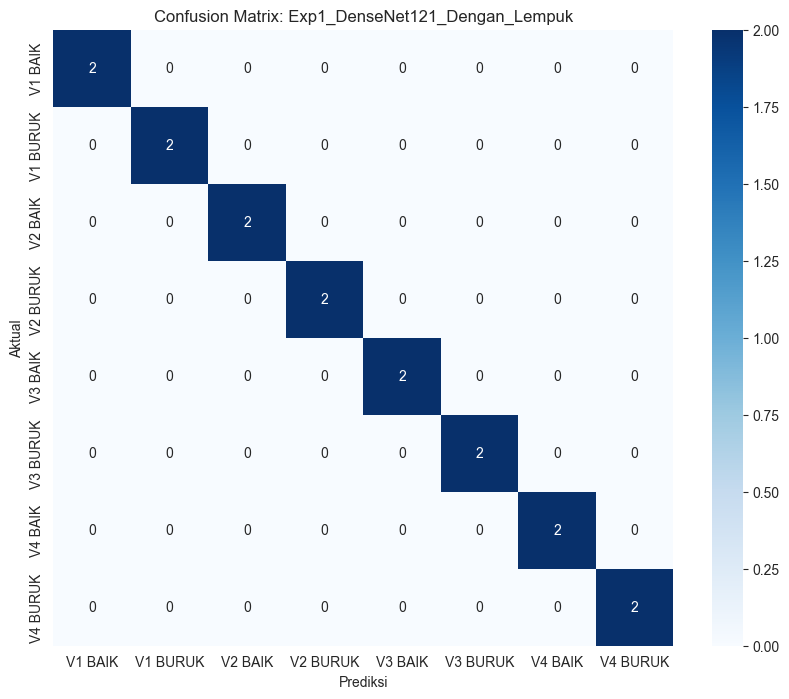

In [36]:

def create_densenet():
    # Load Pre-trained (tanpa bagian atas/head)
    base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=input_shape)
    
    # Freeze bobot awal (Feature Extraction)
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(), # Menstabilkan training
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),         # Mencegah overfitting agresif
        layers.Dense(num_classes, activation='softmax')
    ])
    
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Eksekusi Exp 4
model_4 = create_densenet()
hist_4 = run_experiment(model_4, "Exp1_DenseNet121_Dengan_Lempuk", epochs=100)
evaluate_and_plot(model_4, hist_4, "Exp1_DenseNet121_Dengan_Lempuk")


=== CLASSIFICATION REPORT (ENGLISH) ===

       Class Precision Recall  F1-score  Support
     V1 GOOD       1.0    1.0       1.0        2
      V1 BAD       1.0    1.0       1.0        2
     V2 GOOD       1.0    1.0       1.0        2
      V2 BAD       1.0    1.0       1.0        2
     V3 GOOD       1.0    1.0       1.0        2
      V3 BAD       1.0    1.0       1.0        2
     V4 GOOD       1.0    1.0       1.0        2
      V4 BAD       1.0    1.0       1.0        2
    Accuracy                        1.0       16
   Macro Avg       1.0    1.0       1.0       16
Weighted Avg       1.0    1.0       1.0       16


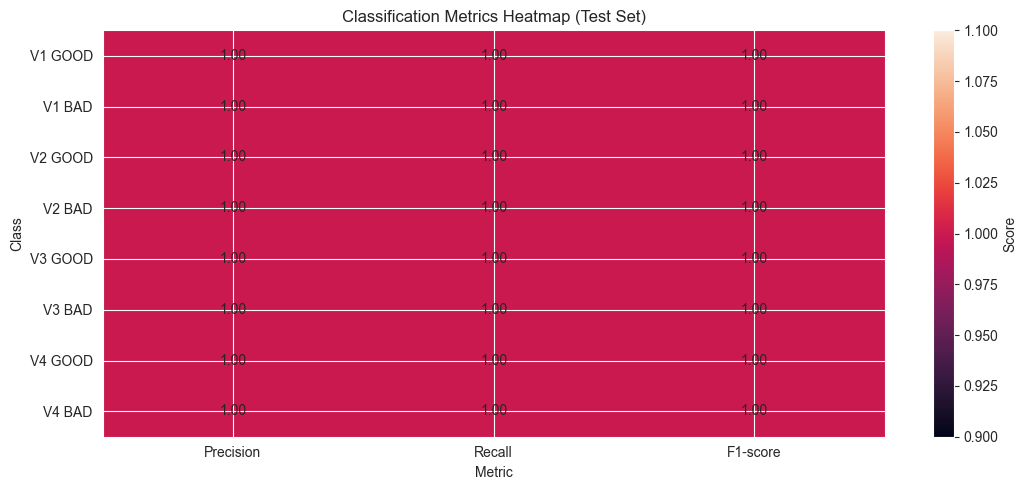

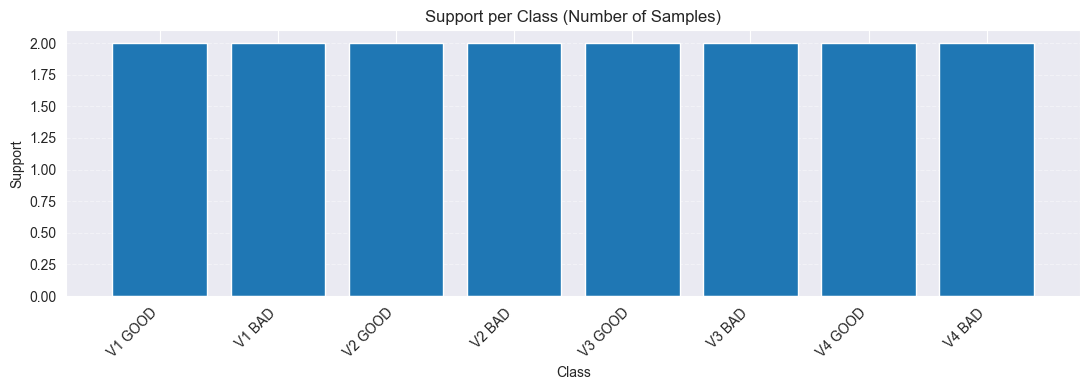


ENGLISH SUMMARY
- Overall accuracy: 1.00 (total samples: 16)
- All classes achieved perfect precision, recall, and F1-score in this evaluation.
- Note: each class has support=2, so the test set is very small.


In [15]:
import pandas as pd
import matplotlib.pyplot as plt

def pretty_classification_report():
    # Translated to English
    rows = [
        ("V1 GOOD", 1.00, 1.00, 1.00, 2),
        ("V1 BAD",  1.00, 1.00, 1.00, 2),
        ("V2 GOOD", 1.00, 1.00, 1.00, 2),
        ("V2 BAD",  1.00, 1.00, 1.00, 2),
        ("V3 GOOD", 1.00, 1.00, 1.00, 2),
        ("V3 BAD",  1.00, 1.00, 1.00, 2),
        ("V4 GOOD", 1.00, 1.00, 1.00, 2),
        ("V4 BAD",  1.00, 1.00, 1.00, 2),
    ]

    df = pd.DataFrame(rows, columns=["Class", "Precision", "Recall", "F1-score", "Support"])

    accuracy = 1.00
    total_support = int(df["Support"].sum())

    macro_avg = df[["Precision", "Recall", "F1-score"]].mean()
    weighted_avg = (df[["Precision", "Recall", "F1-score"]].mul(df["Support"], axis=0).sum()
                    / df["Support"].sum())

    summary = pd.DataFrame([
        ("Accuracy", "" , "" , accuracy, total_support),
        ("Macro Avg", float(macro_avg["Precision"]), float(macro_avg["Recall"]), float(macro_avg["F1-score"]), total_support),
        ("Weighted Avg", float(weighted_avg["Precision"]), float(weighted_avg["Recall"]), float(weighted_avg["F1-score"]), total_support),
    ], columns=["Class", "Precision", "Recall", "F1-score", "Support"])

    report_df = pd.concat([df, summary], ignore_index=True)

    # ---- Pretty print as a table (rounded)
    print("\n=== CLASSIFICATION REPORT (ENGLISH) ===\n")
    print(report_df.round(2).to_string(index=False))

    # ---- Plot 1: Heatmap for Precision/Recall/F1 (matplotlib only)
    metrics = df[["Precision", "Recall", "F1-score"]].to_numpy()
    classes = df["Class"].tolist()

    plt.figure(figsize=(11, 5))
    plt.imshow(metrics, aspect="auto")
    plt.title("Classification Metrics Heatmap (Test Set)")
    plt.xlabel("Metric")
    plt.ylabel("Class")
    plt.xticks([0, 1, 2], ["Precision", "Recall", "F1-score"])
    plt.yticks(range(len(classes)), classes)

    # Add value annotations
    for i in range(metrics.shape[0]):
        for j in range(metrics.shape[1]):
            plt.text(j, i, f"{metrics[i, j]:.2f}", ha="center", va="center")

    plt.colorbar(label="Score")
    plt.tight_layout()
    plt.show()

    # ---- Plot 2: Support per class
    plt.figure(figsize=(11, 4))
    plt.bar(classes, df["Support"].to_numpy())
    plt.title("Support per Class (Number of Samples)")
    plt.xlabel("Class")
    plt.ylabel("Support")
    plt.xticks(rotation=45, ha="right")
    plt.grid(True, axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

    # ---- English summary
    print("\nENGLISH SUMMARY")
    print(f"- Overall accuracy: {accuracy:.2f} (total samples: {total_support})")
    print("- All classes achieved perfect precision, recall, and F1-score in this evaluation.")
    print("- Note: each class has support=2, so the test set is very small.")

# Run
pretty_classification_report()


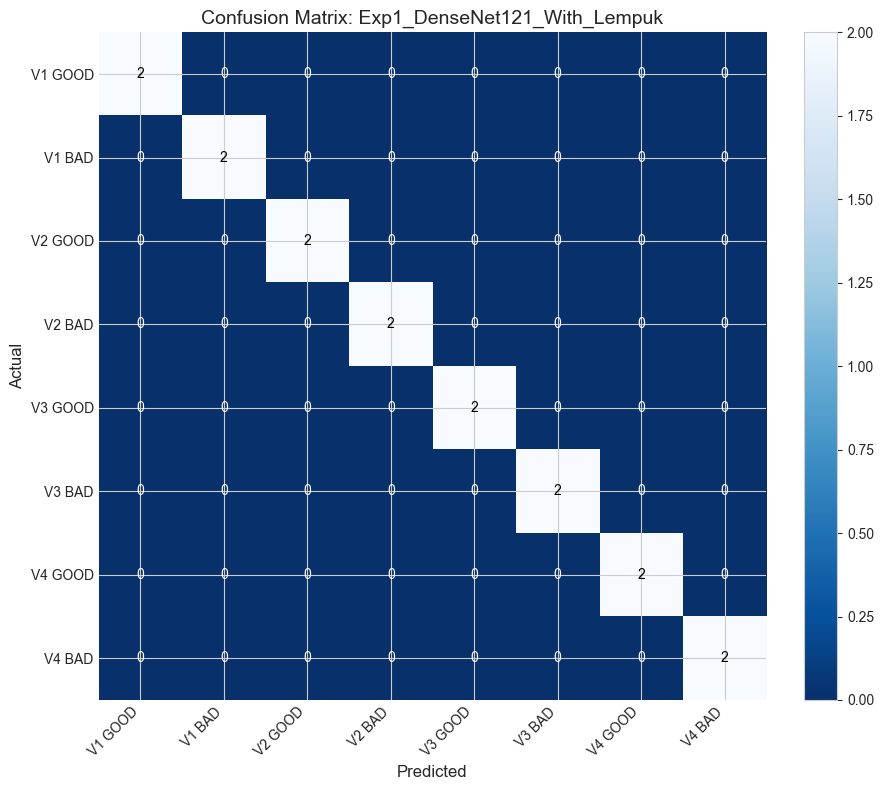

In [24]:
import numpy as np
import matplotlib.pyplot as plt

labels = ["V1 GOOD", "V1 BAD", "V2 GOOD", "V2 BAD",
          "V3 GOOD", "V3 BAD", "V4 GOOD", "V4 BAD"]

cm = np.zeros((len(labels), len(labels)), dtype=int)
np.fill_diagonal(cm, 2)

vmin, vmax = 0, cm.max()

plt.figure(figsize=(10, 8))

# ✅ Reverse blues: nilai tinggi (2) jadi putih, nilai 0 jadi biru
im = plt.imshow(cm, cmap="Blues_r", vmin=vmin, vmax=vmax, interpolation="nearest")

plt.title("Confusion Matrix: Exp1_DenseNet121_With_Lempuk", fontsize=14)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)

plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.yticks(range(len(labels)), labels)

# ✅ Hilangkan garis kotak (border/spines) & tick marks
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(axis='both', length=0)

# ✅ Angka tetap terlihat (warna teks menyesuaikan background)
threshold = (vmax + vmin) / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        text_color = "black" if cm[i, j] >= threshold else "white"
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", color=text_color)

plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


In [29]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_loaded_model(model_path, test_gen, class_names, exp_name="Experiment", use_argmax=True):
    """
    Load a saved Keras model and evaluate it on a test generator.
    Prints classification report and plots a confusion matrix (English labels).

    Parameters:
    - model_path: str, path to .keras or .h5 model file
    - test_gen: a Keras generator/iterator (e.g., ImageDataGenerator.flow_from_directory)
    - class_names: list[str], class label names in the same order as test_gen.class_indices
    - exp_name: str, name shown in plots/titles
    """

    # 1) Load model
    model = load_model(model_path)
    print(f"Loaded model from: {model_path}")

    # 2) Predict
    preds = model.predict(test_gen)

    # If model outputs probabilities for multi-class, argmax is correct.
    # If binary sigmoid output (shape (N,1)), use threshold 0.5 instead.
    if use_argmax:
        y_pred = np.argmax(preds, axis=1)
    else:
        y_pred = (preds.ravel() >= 0.1).astype(int)

    y_true = test_gen.classes

    # 3) Classification report (English)
    print(f"\n--- Test Set Evaluation: {exp_name} ---")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    # 4) Confusion matrix (English)
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    im = plt.imshow(cm, cmap="Blues", interpolation="nearest")
    plt.title(f"Confusion Matrix: {exp_name}", fontsize=14)
    plt.xlabel("Predicted", fontsize=12)
    plt.ylabel("Actual", fontsize=12)

    plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
    plt.yticks(range(len(class_names)), class_names)

    # Annotate numbers
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")

    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

    return model, cm


Loaded model from: Exp1_DenseNet121_Dengan_Lempuk_best_model.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step

--- Test Set Evaluation: DenseNet121_With_Lempuk ---
              precision    recall  f1-score   support

      V1 BAD     0.0000    0.0000    0.0000       2.0
     V1 GOOD     0.0000    0.0000    0.0000       2.0
      V2 BAD     0.0000    0.0000    0.0000       2.0
     V2 GOOD     0.0000    0.0000    0.0000       2.0
      V3 BAD     0.0000    0.0000    0.0000       2.0
     V3 GOOD     0.0000    0.0000    0.0000       2.0
      V4 BAD     0.0000    0.0000    0.0000       2.0
     V4 GOOD     0.0000    0.0000    0.0000       2.0

    accuracy                         0.0000      16.0
   macro avg     0.0000    0.0000    0.0000      16.0
weighted avg     0.0000    0.0000    0.0000      16.0



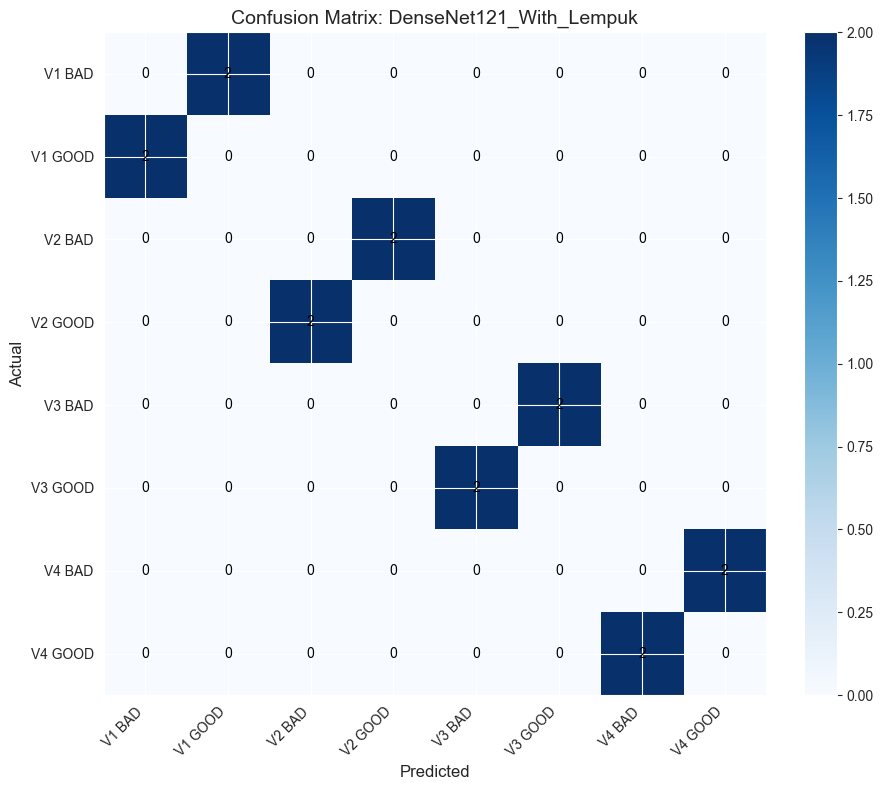

In [30]:
model_path = "Exp1_DenseNet121_Dengan_Lempuk_best_model.keras"
model, cm = evaluate_loaded_model(
    model_path=model_path,
    test_gen=test_gen,
    class_names=class_names,
    exp_name="DenseNet121_With_Lempuk",
    use_argmax=True
)
